<a href="https://colab.research.google.com/github/nishasn10/Aiml_project/blob/main/Lasso_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (3649, 21)

First 5 Rows:
        Entity  Year  Access to electricity (% of population)  \
0  Afghanistan  2000                                 1.613591   
1  Afghanistan  2001                                 4.074574   
2  Afghanistan  2002                                 9.409158   
3  Afghanistan  2003                                14.738506   
4  Afghanistan  2004                                20.064968   

   Access to clean fuels for cooking  \
0                                6.2   
1                                7.2   
2                                8.2   
3                                9.5   
4                               10.9   

   Renewable-electricity-generating-capacity-per-capita  \
0                                               9.22      
1                                               8.86      
2                                               8.47      
3                                               8.09      
4                               

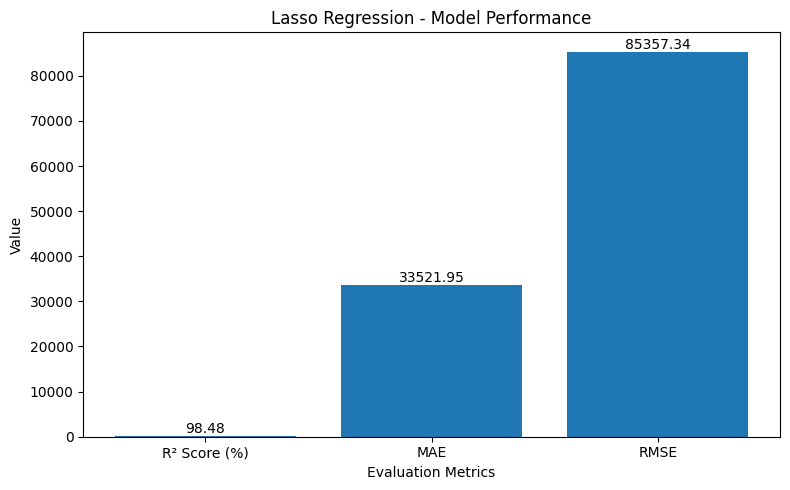

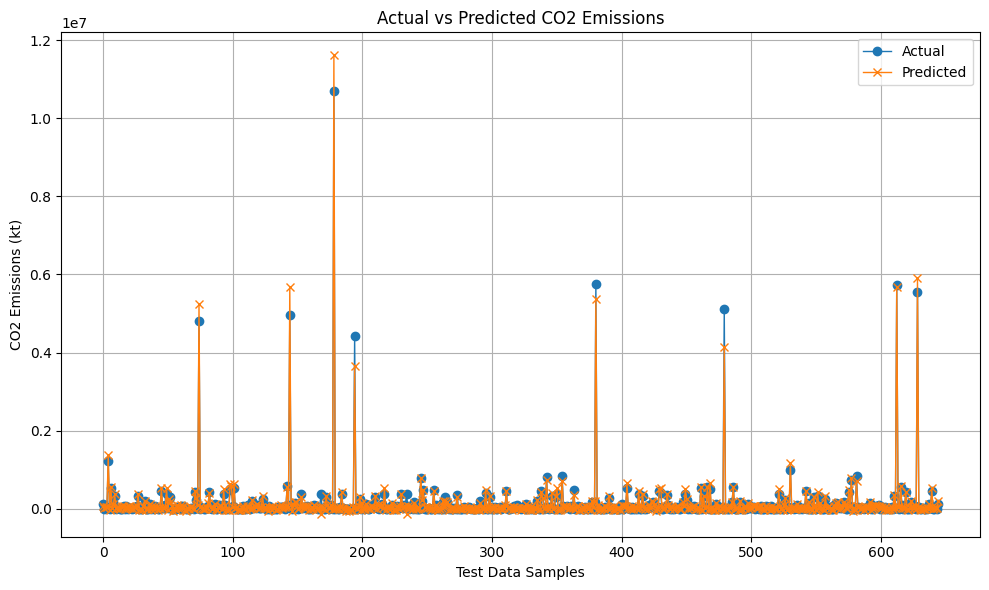

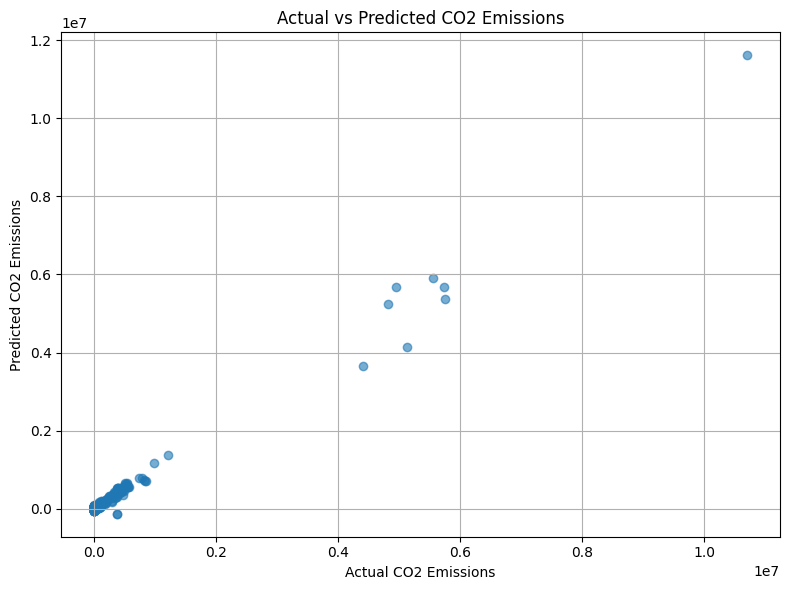

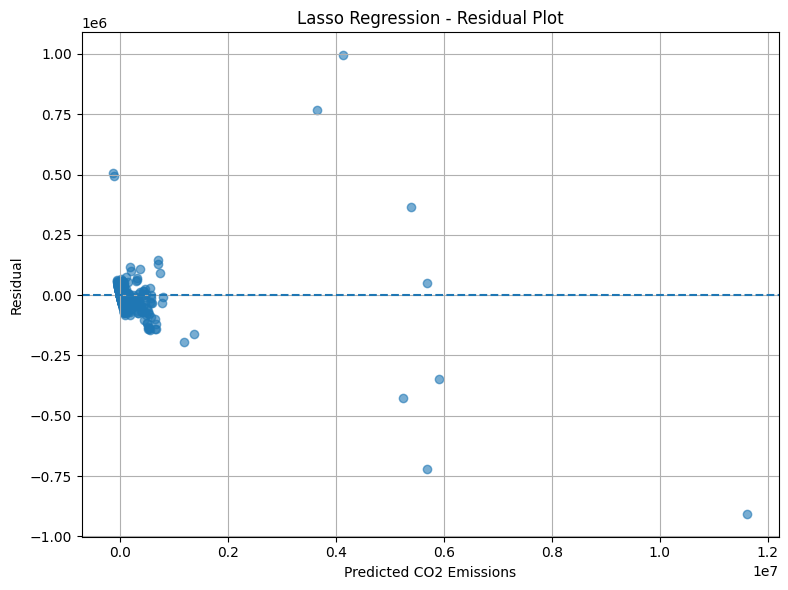


Actual vs Predicted:
         Actual     Predicted
0  1.108500e+05  6.406976e+04
1  1.800000e+02  9.895927e+03
2  5.042000e+04  3.615259e+04
3  7.130000e+03  3.622120e+04
4  1.215210e+06  1.374599e+06
5  1.130000e+03 -3.028376e+04
6  5.370100e+05  5.703105e+05
7  9.240000e+03  2.043593e+04
8  1.856200e+05  1.123379e+05
9  3.285200e+05  3.734062e+05


In [6]:
# ============================================================
# LASSO REGRESSION - GLOBAL SUSTAINABLE ENERGY DATASET
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Lasso
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)


# ============================================================
# 1. LOAD DATASET
# ============================================================

df = pd.read_csv(
    "global-data-on-sustainable-energy (1).csv"
)

print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())


# ============================================================
# 2. CLEAN COLUMN NAMES
# ============================================================

df.columns = df.columns.str.strip()

print("\nColumn Names:")
print(df.columns.tolist())


# ============================================================
# 3. SELECT TARGET
# ============================================================

target = "Value_co2_emissions_kt_by_country"


# ============================================================
# 4. REMOVE ROWS WHERE TARGET IS MISSING
# ============================================================

df = df.dropna(subset=[target])


# ============================================================
# 5. SEPARATE FEATURES AND TARGET
# ============================================================

X = df.drop(columns=[target])

y = df[target]


# ============================================================
# 6. REMOVE ENTITY COLUMN
# ============================================================

# Entity is a country name.
# We remove it to keep the model simple.

if "Entity" in X.columns:
    X = X.drop(columns=["Entity"])


# ============================================================
# 7. CONVERT ALL REMAINING COLUMNS TO NUMERIC
# ============================================================

for column in X.columns:
    X[column] = pd.to_numeric(
        X[column],
        errors="coerce"
    )


# ============================================================
# 8. REMOVE COMPLETELY EMPTY COLUMNS
# ============================================================

X = X.dropna(
    axis=1,
    how="all"
)


# ============================================================
# 9. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)


# ============================================================
# 10. PREPROCESSING
# ============================================================

preprocessor = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])


# ============================================================
# 11. CREATE LASSO REGRESSION MODEL
# ============================================================

lasso_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "lasso",
        Lasso(
            alpha=0.1,
            max_iter=10000
        )
    )
])


# ============================================================
# 12. TRAIN MODEL
# ============================================================

lasso_model.fit(
    X_train,
    y_train
)


# ============================================================
# 13. PREDICTION
# ============================================================

y_pred = lasso_model.predict(
    X_test
)


# ============================================================
# 14. MODEL EVALUATION
# ============================================================

r2 = r2_score(
    y_test,
    y_pred
)

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)


# ============================================================
# 15. DISPLAY RESULTS
# ============================================================

print("\n========================================")
print("LASSO REGRESSION RESULTS")
print("========================================")

print(f"R² Score: {r2:.4f}")
print(f"R² Score (%): {r2 * 100:.2f}%")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")


# ============================================================
# 16. BAR CHART - MODEL PERFORMANCE
# ============================================================

metrics = [
    "R² Score (%)",
    "MAE",
    "RMSE"
]

values = [
    r2 * 100,
    mae,
    rmse
]

plt.figure(figsize=(8, 5))

plt.bar(
    metrics,
    values
)

plt.xlabel("Evaluation Metrics")
plt.ylabel("Value")

plt.title(
    "Lasso Regression - Model Performance"
)

for i, value in enumerate(values):
    plt.text(
        i,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.show()


# ============================================================
# 17. LINE CHART - ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    y_test.values,
    label="Actual",
    marker="o",
    linewidth=1
)

plt.plot(
    y_pred,
    label="Predicted",
    marker="x",
    linewidth=1
)

plt.xlabel("Test Data Samples")

plt.ylabel(
    "CO2 Emissions (kt)"
)

plt.title(
    "Actual vs Predicted CO2 Emissions"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# 18. SCATTER PLOT - ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

plt.xlabel(
    "Actual CO2 Emissions"
)

plt.ylabel(
    "Predicted CO2 Emissions"
)

plt.title(
    "Actual vs Predicted CO2 Emissions"
)

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# 19. RESIDUAL PLOT
# ============================================================

residuals = y_test.values - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel(
    "Predicted CO2 Emissions"
)

plt.ylabel(
    "Residual"
)

plt.title(
    "Lasso Regression - Residual Plot"
)

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# 20. PREDICTION COMPARISON TABLE
# ============================================================

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print("\nActual vs Predicted:")
print(comparison.head(10))